# Heyy
This model is a simple CNN inspired by the VGG architecture, made by a 20yo student, featuring BatchNormalization and Dropout, the dataset was found at https://www.cs.toronto.edu/~kriz/cifar.html, download it and connect it in the dataset section. <br>
Trained 15min on Intel i7 CPU, ~80% test accuracy

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
import numpy as np
import os

2026-02-06 10:14:22.821819: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-06 10:14:23.220032: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-06 10:14:25.265707: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Dataset

In [2]:
import pickle
path='../../Datasets/cifar-10-python/cifar-10-batches-py'
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes') # decoding bytes
    return dict

X_train, X_test, y_train, y_test = [], [], [], []
for _,_,files in os.walk(path):
    for file in files:
        try:
            path_file = os.path.join(path,file)
            if file == "test_batch":
                data = unpickle(path_file)
                X_test = data[b'data'] # decoding bytes
                y_test = data[b'labels']
            elif file == "batches.meta" or file == "readme.html":
                continue
            else:
                data = unpickle(path_file)
                X_train.append(data[b'data'])
                y_train.append(data[b'labels'])
        except Exception as ex:
            print(f'something wrong reading : {file}, {ex}')

X_train = np.concatenate(X_train, axis=0) / 255
y_train = np.concatenate(y_train, axis=0)
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_train = tf.keras.utils.to_categorical(y_train, 10)

X_test = np.concatenate(X_test, axis=0) / 255
y_test = np.array(y_test)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# img = X_train[0].reshape(3, 32, 32).transpose(1, 2, 0)
# plt.imshow(img)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
batch_size = 32
train_dataset = train_dataset.shuffle(buffer_size=50000)\
    .batch(batch_size, drop_remainder=True)\
    .prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
batch_size = 32
test_dataset = test_dataset.shuffle(buffer_size=50000)\
    .batch(batch_size, drop_remainder=True)\
    .prefetch(tf.data.AUTOTUNE)

/tmp/ipykernel_11346/184670584.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes') # decoding bytes


# Model
Architecure : VGG-net inspired

In [3]:
model = tf.keras.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Conv2D(32,kernel_size=4, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.1),
    keras.layers.Conv2D(32,kernel_size=4, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.1),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.2),

    keras.layers.Conv2D(64,kernel_size=4, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.1),
    keras.layers.Conv2D(64,kernel_size=4, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.1),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.3),

    keras.layers.Conv2D(128,kernel_size=4, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.1),
    keras.layers.Conv2D(128,kernel_size=4, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.1),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.4),

    keras.layers.Flatten(),
    keras.layers.Dense(128),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10),
    keras.layers.Softmax()

], name = "Cifar_CNN")

opt = keras.optimizers.Adam()
loss_fn = keras.losses.CategoricalCrossentropy()

model.summary()

Model: "Cifar_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             

 Total params: 775,754 (2.96 MB)

 Trainable params: 774,602 (2.95 MB)

 Non-trainable params: 1,152 (4.50 KB)

# Training

In [4]:
def trainingEvolution(history):
	# plot loss
	plt.subplot(211)
	plt.title('Categrical cross entropy loss')
	plt.plot(history.history['loss'], color='blue', label='train')
	plt.plot(history.history['val_loss'], color='orange', label='test')
	plt.legend()
	# plot accuracy
	plt.subplot(212)
	plt.title('Classification accuracy')
	plt.plot(history.history['accuracy'], color='blue', label='train')
	plt.plot(history.history['val_accuracy'], color='orange', label='test')
	plt.legend()
	plt.show()

def train():
    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])
    history = model.fit(train_dataset, epochs=10, validation_data=test_dataset)
    trainingEvolution(history)
    model.save('Cifar10.keras')

# train()

# Results
picking a random example from the testset and predicting it <br>
execute this cell as much as you want ;)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
pred : automobile with probability : 0.96, correct class : automobile


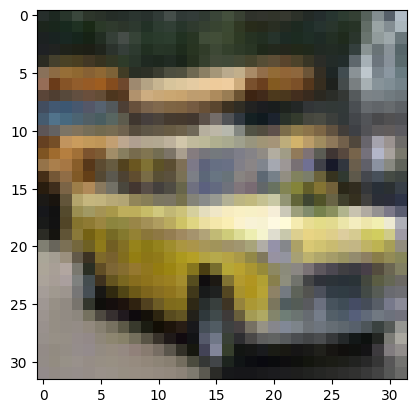

In [27]:
model = keras.models.load_model("Cifar10.keras")
for images, labels in test_dataset.shuffle(1000).take(1):
    img = images[0]
    lab = labels[0]
    plt.imshow(img)

    res = model.predict(np.reshape(img,(-1,32,32,3)))
    idx = np.argmax(res)
    val = res[0][idx]

    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    print(f"pred : {classes[idx]} with probability : {val:.2f}, correct class : {classes[np.argmax(lab)]}")

# Conclusion
Works kinda well, to improve it further I would use data augmentation